# ViT-B/16 — WaRP-C 28-Class Waste Classification
**EEEM068 Applied Machine Learning | University of Surrey**

## Install Libraries

In [1]:
# we need timm for the ViT model, seaborn for plots, sklearn for metrics
!pip install timm seaborn scikit-learn -q

## Unzip Dataset

In [2]:
# unzip the preprocessed WaRP-C dataset that we uploaded to Colab
!unzip -q "/content/WaRP-C-preprocessed (8).zip" -d /content/

## Imports & Setup

In [3]:
import os, io, math, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
)
from sklearn.preprocessing import label_binarize

print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.is_available()}")

PyTorch : 2.10.0+cu128
GPU     : True


## Configuration

In [4]:
# all our settings are in one place so its easy to change things
# we set the seed everywhere so our results are reproducible each run
TRAIN_FOLDER      = "/content/train"
VAL_FOLDER        = "/content/val"
TEST_FOLDER       = "/content/test"
RESULTS_DIR       = "./results"
NUMBER_OF_CLASSES = 28
IMAGE_SIZE        = 224
BATCH_SIZE        = 32
NUMBER_OF_EPOCHS  = 20
LEARNING_RATE     = 2e-5
RANDOM_SEED       = 42

os.makedirs(RESULTS_DIR, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on : {device}")

Running on : cuda


## Image Transforms

In [5]:
# ViT was pretrained using ImageNet normalisation so we have to match it
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# we only augment training images — val and test should stay consistent
# the augmentations mimic real conditions on a recycling conveyor belt
training_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms ready.")

Transforms ready.


## Custom Dataset — 28 Sub-classes



In [6]:
# WaRP-C has two folder levels: superclass/subclass/image.jpg
# PyTorch's built-in ImageFolder would only see the 5 superclasses
# so we wrote our own dataset class to go one level deeper and get all 28 subclasses
class WaRPDataset28(Dataset):
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    def __init__(self, root, transform=None):
        root = Path(root)
        self.transform = transform
        self.samples   = []

        subclass_folders = sorted([
            sub
            for superclass in sorted(root.iterdir()) if superclass.is_dir()
            for sub in sorted(superclass.iterdir()) if sub.is_dir()
        ])

        self.classes      = [s.name for s in subclass_folders]
        self.class_to_idx = {name: i for i, name in enumerate(self.classes)}

        for folder in subclass_folders:
            label = self.class_to_idx[folder.name]
            for img_path in sorted(folder.iterdir()):
                if img_path.suffix.lower() in self.IMG_EXTS:
                    self.samples.append((img_path, label))

        self.targets = [label for _, label in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = WaRPDataset28(TRAIN_FOLDER, transform=training_transforms)
val_dataset   = WaRPDataset28(VAL_FOLDER,   transform=eval_transforms)
test_dataset  = WaRPDataset28(TEST_FOLDER,  transform=eval_transforms)

class_names = train_dataset.classes

print(f"Classes           : {len(class_names)}")
print(f"Training images   : {len(train_dataset)}")
print(f"Validation images : {len(val_dataset)}")
print(f"Test images       : {len(test_dataset)}")

assert train_dataset.classes == val_dataset.classes == test_dataset.classes, \
    "Class lists don't match — check folder names"
print("Class lists consistent across all splits.")

Classes           : 28
Training images   : 7058
Validation images : 1765
Test images       : 1551
Class lists consistent across all splits.


## Class Distribution

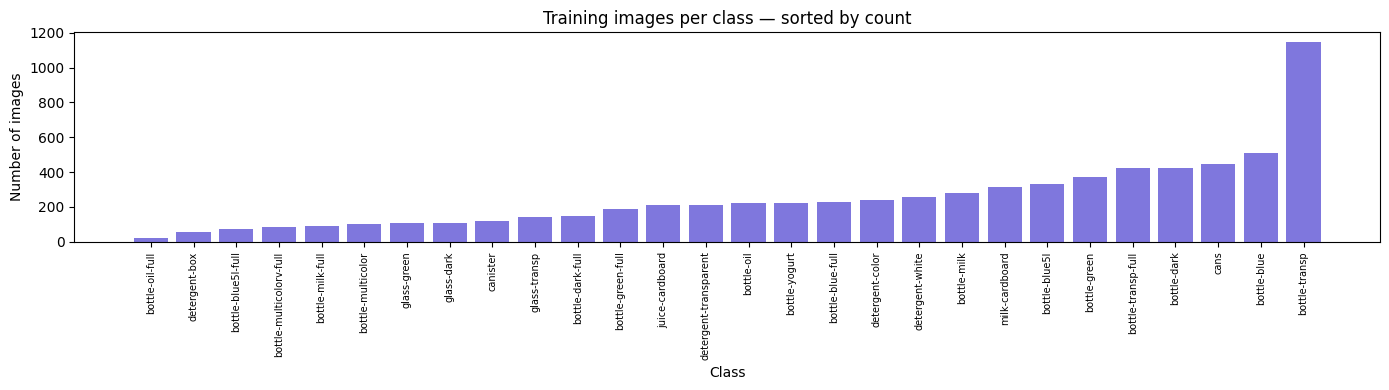

Rarest  : bottle-oil-full (19 images)
Largest : bottle-transp (1145 images)
Imbalance ratio : 60.3x


In [7]:
# we plotted this to understand how unbalanced the dataset is before training
# bottle-oil-full only has 19 images while bottle-transp has 1145 — that's 60x difference
images_per_class = Counter(train_dataset.targets)
sorted_classes   = sorted(images_per_class.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(
    [class_names[i] for i, _ in sorted_classes],
    [count for _, count in sorted_classes],
    color="#7F77DD"
)
ax.set_title("Training images per class — sorted by count")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/class_distribution.png", dpi=150)
plt.show()

rarest  = min(images_per_class, key=images_per_class.get)
largest = max(images_per_class, key=images_per_class.get)
print(f"Rarest  : {class_names[rarest]} ({images_per_class[rarest]} images)")
print(f"Largest : {class_names[largest]} ({images_per_class[largest]} images)")
print(f"Imbalance ratio : {images_per_class[largest] / images_per_class[rarest]:.1f}x")

## Imbalance Handling — WeightedRandomSampler

WaRP-C is heavily imbalanced (up to 60x ratio). We fix this at two levels:
- **Sampler**: rare classes are picked more often each epoch
- **Loss**: mistakes on rare classes carry a higher penalty

In [8]:
# with a 60x imbalance the model would just ignore rare classes
# WeightedRandomSampler makes each class appear roughly equally each epoch
# by giving images from rare classes a higher chance of being picked
sample_weights = [1.0 / images_per_class[label] for label in train_dataset.targets]

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

print("WeightedRandomSampler ready.")

WeightedRandomSampler ready.


## Data Loaders

In [9]:
# training uses the weighted sampler instead of shuffle
# val and test just go in order since we dont want randomness there
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=weighted_sampler, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 221
Val batches   : 56
Test batches  : 49


## Model — ViT-B/16

In [10]:
# ViT splits each image into 14x14 patches and uses self-attention
# to understand relationships between patches across the whole image
# we load the pretrained weights and just replace the final layer with 28 outputs
vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=NUMBER_OF_CLASSES,
)
vit_model = vit_model.to(device)

total_params = sum(p.numel() for p in vit_model.parameters())
print(f"ViT-B/16 loaded = {total_params / 1e6:.1f}M parameters")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16 loaded = 85.8M parameters


## Loss, Optimiser & Scheduler

In [11]:
# we handle imbalance at the loss level too — rare class mistakes cost more
# the weight formula gives higher penalty to classes with fewer samples
class_weights = torch.tensor([
    len(train_dataset) / (NUMBER_OF_CLASSES * images_per_class[i])
    for i in range(NUMBER_OF_CLASSES)
], dtype=torch.float32).to(device)

loss_function = nn.CrossEntropyLoss(weight=class_weights)

# AdamW works well for transformers, weight decay helps avoid overfitting
optimiser = torch.optim.AdamW(
    vit_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01
)
# cosine annealing gradually reduces lr to near zero by the last epoch
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=NUMBER_OF_EPOCHS
)

print("Loss, optimiser and scheduler ready.")

Loss, optimiser and scheduler ready.


## Training & Validation Functions

In [12]:
def train_one_epoch(model, loader, loss_fn, opt):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        predictions    = model(images)
        loss           = loss_fn(predictions, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item() * images.size(0)
        correct    += (predictions.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        predictions    = model(images)
        loss           = loss_fn(predictions, labels)

        total_loss += loss.item() * images.size(0)
        correct    += (predictions.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total

## Training Loop

In [13]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_accuracy = 0.0
best_model_path   = f"{RESULTS_DIR}/vit_best_model.pth"

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>10}  {'Train Acc':>10}  {'Val Acc':>10}")


for epoch in range(NUMBER_OF_EPOCHS):
    train_loss, train_acc = train_one_epoch(vit_model, train_loader, loss_function, optimiser)
    val_loss,   val_acc   = evaluate(vit_model, val_loader, loss_function)
    lr_scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(vit_model.state_dict(), best_model_path)
        marker = "  <- best"

    print(f"{epoch+1:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  {train_acc:>10.3f}  {val_acc:>10.3f}{marker}")

print(f"\nBest val accuracy : {best_val_accuracy:.4f}")

 Epoch  Train Loss    Val Loss   Train Acc     Val Acc
     1      1.2314      1.3804       0.485       0.553  <- best
     2      0.3215      1.3090       0.802       0.598  <- best
     3      0.2064      1.1121       0.866       0.670  <- best
     4      0.1202      1.1014       0.915       0.679  <- best
     5      0.0779      0.8821       0.940       0.748  <- best
     6      0.0599      0.8393       0.950       0.769  <- best
     7      0.0388      0.9239       0.967       0.754
     8      0.0346      0.9054       0.969       0.760
     9      0.0252      0.8499       0.976       0.773  <- best
    10      0.0204      0.8805       0.980       0.772
    11      0.0142      0.8559       0.985       0.782  <- best
    12      0.0106      0.8172       0.989       0.790  <- best
    13      0.0104      0.8246       0.988       0.793  <- best
    14      0.0078      0.8160       0.990       0.801  <- best
    15      0.0084      0.8385       0.991       0.803  <- best
    16      

## Training Curves

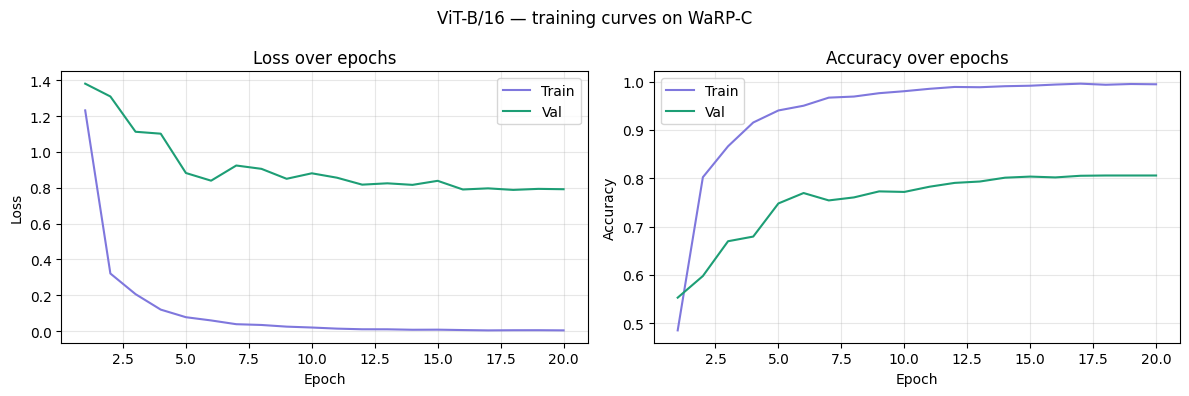

Saved training_curves.png


In [14]:
# plotting both loss and accuracy together makes it easy to spot overfitting
# in our case train accuracy reaches 99% while val stays around 80%
# which is expected given the dataset size
epochs_x = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_x, history["train_loss"], label="Train", color="#7F77DD")
axes[0].plot(epochs_x, history["val_loss"],   label="Val",   color="#1D9E75")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["train_acc"], label="Train", color="#7F77DD")
axes[1].plot(epochs_x, history["val_acc"],   label="Val",   color="#1D9E75")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("ViT-B/16 — training curves on WaRP-C", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")

## Final Evaluation on Test Set

In [15]:
# we load the best checkpoint not the last epoch
# the test set has never been seen during training or validation
vit_model.load_state_dict(torch.load(best_model_path, map_location=device))
vit_model.eval()

all_predictions, all_true_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = vit_model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_probs       = np.array(all_probs)

test_accuracy  = (all_predictions == all_true_labels).mean()
test_precision = precision_score(all_true_labels, all_predictions, average="macro", zero_division=0)
test_recall    = recall_score(all_true_labels, all_predictions, average="macro", zero_division=0)
test_f1_macro  = f1_score(all_true_labels, all_predictions, average="macro", zero_division=0)

true_bin = label_binarize(all_true_labels, classes=list(range(NUMBER_OF_CLASSES)))
test_auc = roc_auc_score(true_bin, all_probs, multi_class="ovr", average="macro")
test_map = average_precision_score(true_bin, all_probs, average="macro")

print("Test set results")
print(f"  Accuracy  : {test_accuracy:.4f}")
print(f"  Precision : {test_precision:.4f}")
print(f"  Recall    : {test_recall:.4f}")
print(f"  F1 macro  : {test_f1_macro:.4f}")
print(f"  AUC       : {test_auc:.4f}")
print(f"  mAP       : {test_map:.4f}")
print()
print(classification_report(all_true_labels, all_predictions, target_names=class_names, digits=3))

Test set results
  Accuracy  : 0.8034
  Precision : 0.7990
  Recall    : 0.8031
  F1 macro  : 0.7956
  AUC       : 0.9887
  mAP       : 0.8619

                         precision    recall  f1-score   support

            bottle-blue      0.733     0.740     0.737       104
       bottle-blue-full      0.690     0.674     0.682        43
          bottle-blue5l      0.797     0.875     0.834        72
     bottle-blue5l-full      0.741     0.833     0.784        24
            bottle-dark      0.916     0.916     0.916        95
       bottle-dark-full      0.789     0.882     0.833        34
           bottle-green      0.833     0.878     0.855        74
      bottle-green-full      0.762     0.941     0.842        34
            bottle-milk      0.726     0.789     0.756        57
       bottle-milk-full      0.760     0.905     0.826        21
      bottle-multicolor      0.833     0.357     0.500        28
bottle-multicolorv-full      0.630     0.810     0.708        21
          

## Confusion Matrix

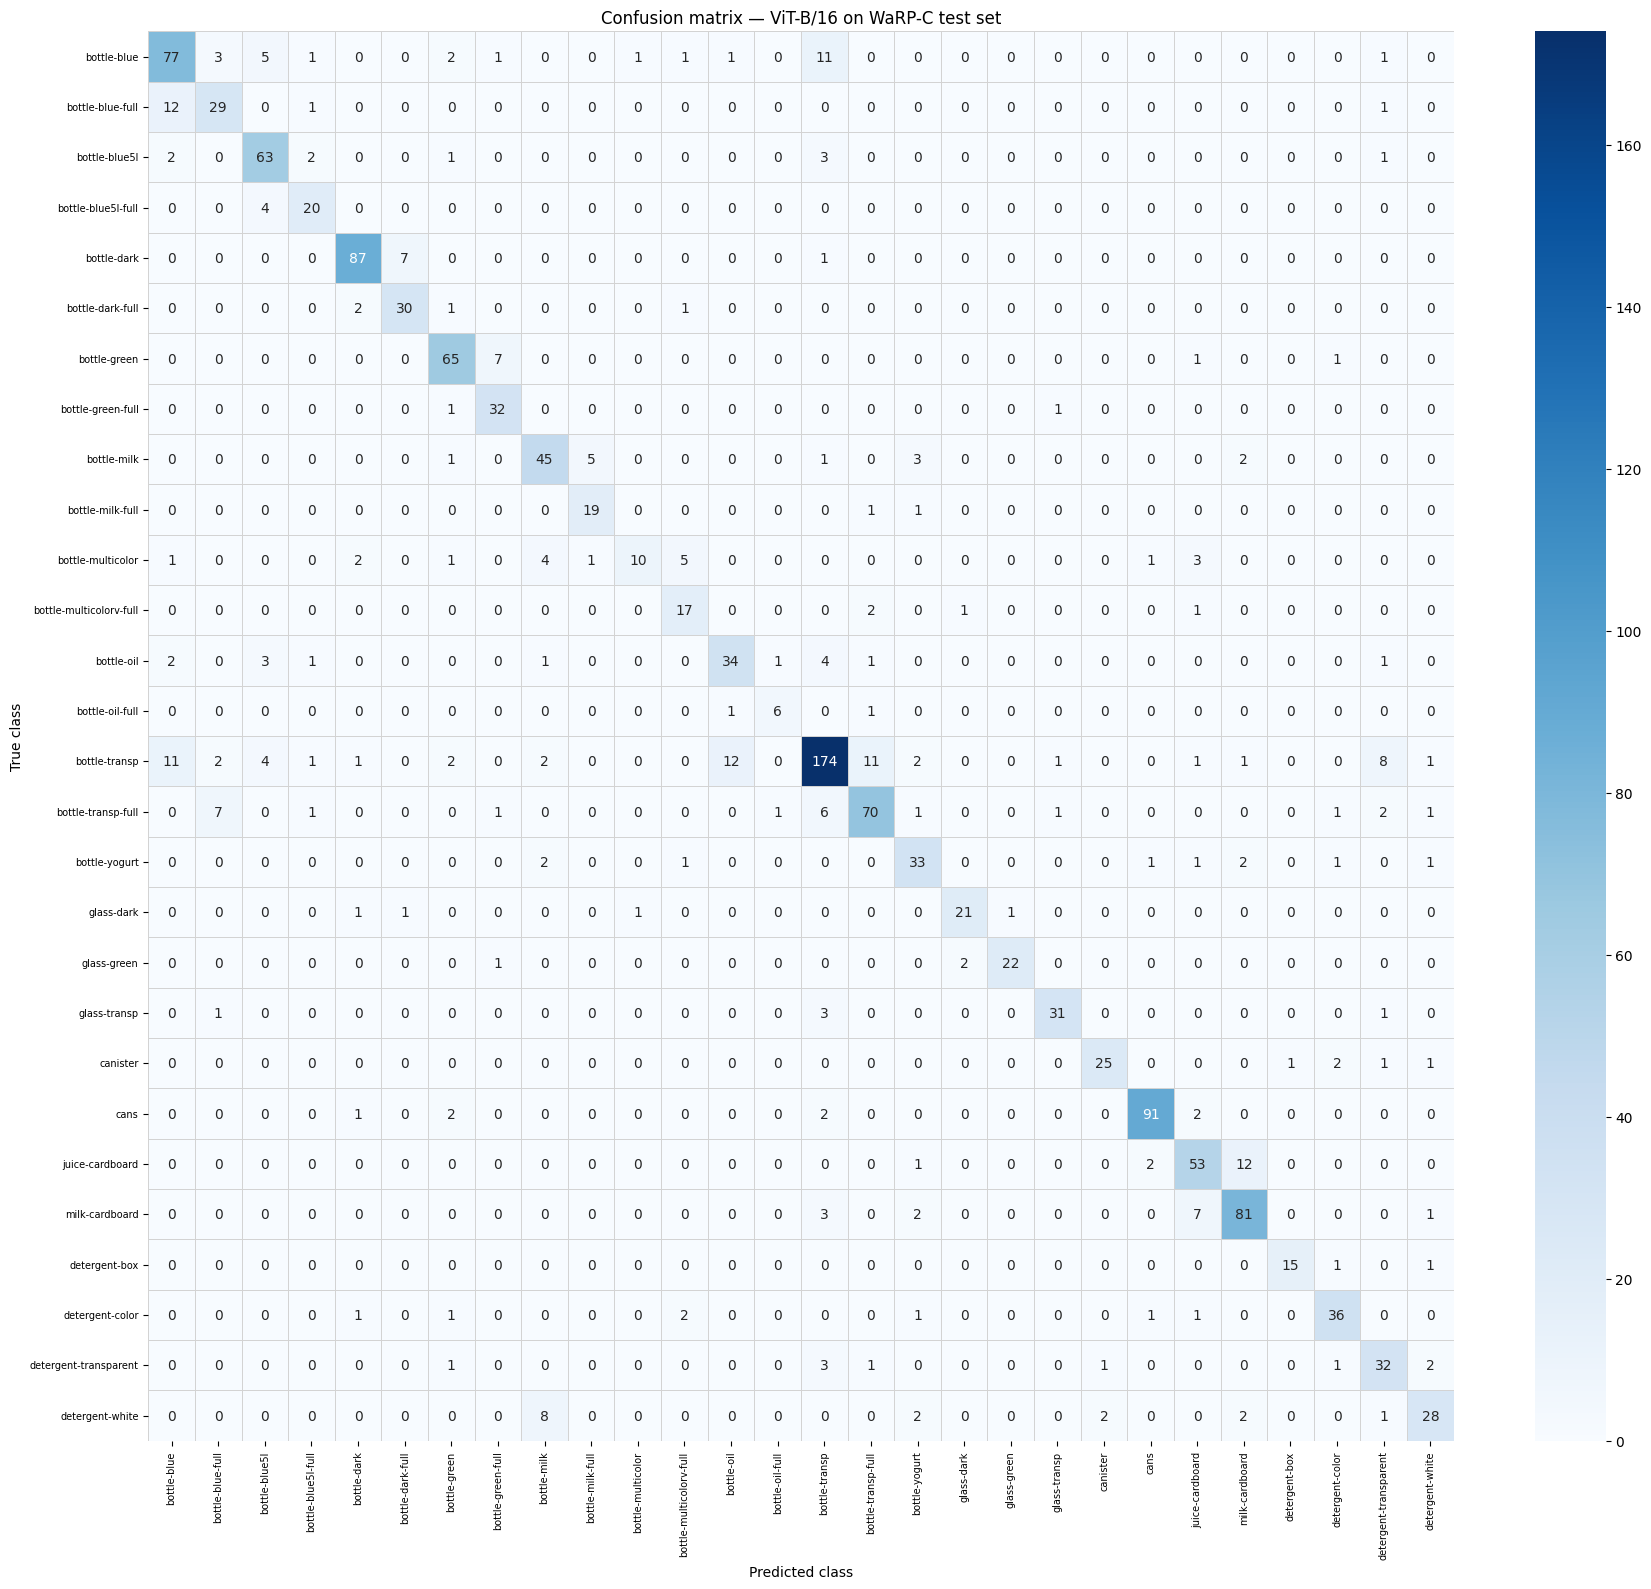

Saved confusion_matrix.png


In [16]:
# rows are true labels, columns are predictions
# the diagonal should be the darkest — off-diagonal values show where the model gets confused
# bottle-multicolor and bottle-oil-full were the hardest based on our results
conf_matrix = confusion_matrix(all_true_labels, all_predictions)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.4, linecolor="lightgrey", ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Confusion matrix — ViT-B/16 on WaRP-C test set")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150)
plt.show()
print("Saved confusion_matrix.png")

## Per-Class F1

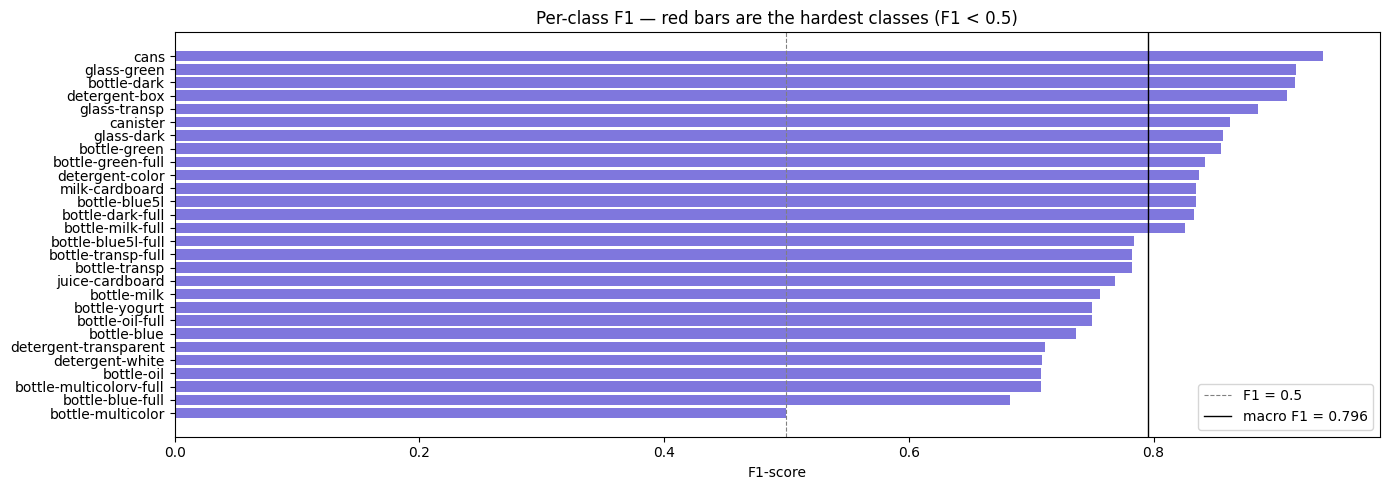

Saved per_class_f1.png


In [17]:
# sorting by F1 score shows which classes the model struggles with most
# red bars (F1 < 0.5) are the ones we need to discuss in the report
per_class_f1  = f1_score(all_true_labels, all_predictions, average=None, zero_division=0)
sorted_order  = np.argsort(per_class_f1)
sorted_names  = [class_names[i] for i in sorted_order]
sorted_scores = per_class_f1[sorted_order]
bar_colours   = ["#E24B4A" if s < 0.5 else "#7F77DD" for s in sorted_scores]

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(sorted_names, sorted_scores, color=bar_colours)
ax.axvline(x=0.5, color="grey", linestyle="--", linewidth=0.8, label="F1 = 0.5")
ax.axvline(x=test_f1_macro, color="black", linestyle="-", linewidth=1,
           label=f"macro F1 = {test_f1_macro:.3f}")
ax.set_xlabel("F1-score")
ax.set_title("Per-class F1 — red bars are the hardest classes (F1 < 0.5)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_class_f1.png", dpi=150)
plt.show()
print("Saved per_class_f1.png")

## Post-Training INT8 Quantisation

Converts Linear layer weights from float32 to int8 - no retraining needed.
This makes the model smaller and faster on CPU, useful for deployment without a GPU.

In [18]:
# quantisation converts the model weights from 32-bit floats to 8-bit integers
# this makes the model 74% smaller (327MB → 84MB) which is useful for deployment
# we compared both versions on accuracy and speed to analyse the trade-off
def get_model_size_mb(model):
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return buf.tell() / (1024 ** 2)


def measure_speed(model, loader, num_batches=30):
    model.eval()
    model.to("cpu")
    times = []
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= num_batches: break
            t0 = time.perf_counter()
            model(images.cpu())
            times.append((time.perf_counter() - t0) / images.size(0) * 1000)
    model.to(device)
    return float(np.mean(times))


def get_accuracy_on_cpu(model, loader, num_batches=40):
    model.eval()
    model.to("cpu")
    correct, total = 0, 0
    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            if i >= num_batches: break
            preds    = model(images.cpu()).argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    model.to(device)
    return correct / total


# load best weights into a fresh model for clean comparison
fp32_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=NUMBER_OF_CLASSES)
fp32_model.load_state_dict(torch.load(best_model_path, map_location="cpu"))
fp32_model.eval()

# one line converts Linear layers to INT8 - no retraining needed
int8_model = torch.quantization.quantize_dynamic(
    fp32_model, {nn.Linear}, dtype=torch.qint8
)

print("Measuring FP32...")
fp32_size     = get_model_size_mb(fp32_model)
fp32_speed    = measure_speed(fp32_model, test_loader)
fp32_accuracy = get_accuracy_on_cpu(fp32_model, test_loader)

print("Measuring INT8...")
int8_size     = get_model_size_mb(int8_model)
int8_speed    = measure_speed(int8_model, test_loader)
int8_accuracy = get_accuracy_on_cpu(int8_model, test_loader)

print(" Quantisation results /n")
print(f"{'Metric':<22} {'FP32':>10}  {'INT8':>10}  {'Change':>10}")
print(f"{'Model size (MB)':<22} {fp32_size:>10.1f}  {int8_size:>10.1f}  {(int8_size-fp32_size)/fp32_size*100:>+9.1f}%")
print(f"{'Accuracy':<22} {fp32_accuracy:>10.4f}  {int8_accuracy:>10.4f}  {(int8_accuracy-fp32_accuracy)*100:>+9.2f}pp")
print(f"{'Speed (ms/image)':<22} {fp32_speed:>10.2f}  {int8_speed:>10.2f}  {fp32_speed/int8_speed:>9.1f}x faster")


/tmp/ipykernel_9177/844294210.py:44: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  int8_model = torch.quantization.quantize_dynamic(


Measuring FP32...
Measuring INT8...
 Quantisation results /n
Metric                       FP32        INT8      Change
Model size (MB)             327.4        84.4      -74.2%
Accuracy                   0.8039      0.7969      -0.70pp
Speed (ms/image)           356.98      329.63        1.1x faster


## Quantisation Comparison Chart

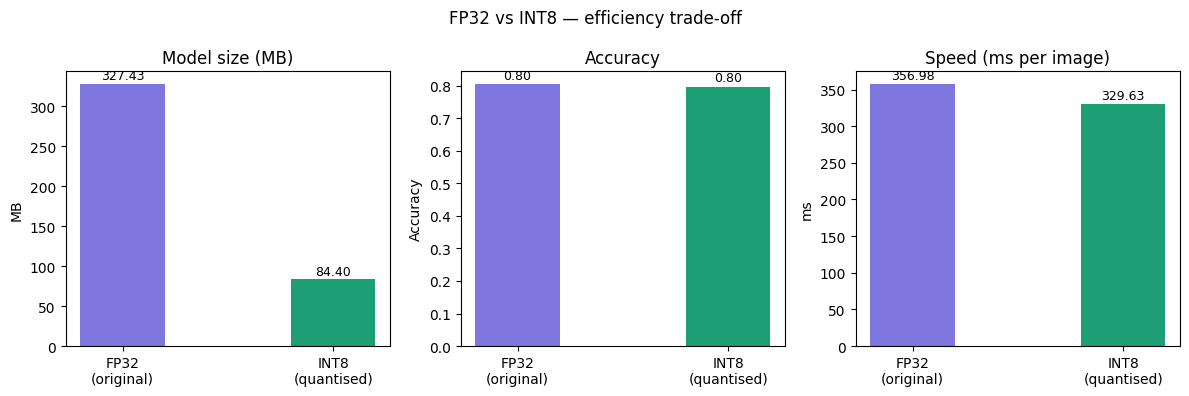

Saved quantisation_tradeoff.png


In [19]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels_x = ["FP32\n(original)", "INT8\n(quantised)"]
colours  = ["#7F77DD", "#1D9E75"]

for ax, values, title, ylabel in zip(
    axes,
    [[fp32_size, int8_size], [fp32_accuracy, int8_accuracy], [fp32_speed, int8_speed]],
    ["Model size (MB)", "Accuracy", "Speed (ms per image)"],
    ["MB", "Accuracy", "ms"],
):
    bars = ax.bar(labels_x, values, color=colours, width=0.4)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("FP32 vs INT8 — efficiency trade-off", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/quantisation_tradeoff.png", dpi=150)
plt.show()
print("Saved quantisation_tradeoff.png")

## Final Summary

In [20]:
print("  FINAL SUMMARY — ViT-B/16 on WaRP-C")
print(f"  Test Accuracy   : {test_accuracy:.4f}")
print(f"  Test Precision  : {test_precision:.4f}")
print(f"  Test Recall     : {test_recall:.4f}")
print(f"  Test F1 (macro) : {test_f1_macro:.4f}")
print(f"  Test AUC        : {test_auc:.4f}")
print(f"  Test mAP        : {test_map:.4f}")
print(f"  FP32 size       : {fp32_size:.1f} MB")
print(f"  INT8 size       : {int8_size:.1f} MB ({(1-int8_size/fp32_size)*100:.0f}% smaller)")
print(f"  Speedup         : {fp32_speed/int8_speed:.1f}x faster on CPU")
print(f"\nResults saved to: {RESULTS_DIR}/")

  FINAL SUMMARY — ViT-B/16 on WaRP-C
  Test Accuracy   : 0.8034
  Test Precision  : 0.7990
  Test Recall     : 0.8031
  Test F1 (macro) : 0.7956
  Test AUC        : 0.9887
  Test mAP        : 0.8619
  FP32 size       : 327.4 MB
  INT8 size       : 84.4 MB (74% smaller)
  Speedup         : 1.1x faster on CPU

Results saved to: ./results/
